# Queueing Model Evaluation For Paper Figures

This notebook assembles the paper figures for one consistent three-node repeater setting:

`N1 ==== 32 km ==== N2 ==== 18 km ==== N3`

The workflow is organized in four parts:

1. A swap trace that shows how one tracked end memory evolves through heralding, waiting, swapping, and confirmation.
2. Two behavior sweeps for the same `1:1` configuration: one versus requested fidelity and one versus long-link cutoff.
3. Allocation-level validation against SeQUeNCe for multiplexing and non-multiplexing.
4. A final accepted-rate comparison that shows what is gained by using model-selected TTLs.


In [110]:
from pathlib import Path
import json
import os
import sys
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'sequence').exists() and (candidate / 'example' / 'queueing_model').exists():
            return candidate
    raise RuntimeError(f'Could not find SeQUeNCe repo root from {start}')


REPO_ROOT = find_repo_root(Path.cwd())
QUEUEING_DIR = REPO_ROOT / 'example' / 'queueing_model'
CORE_QUEUEING_DIR = REPO_ROOT / 'example' / 'queueing_model'
CORE_EXPERIMENT_DIR = REPO_ROOT / 'example' / 'entanglement_distribution_experiment'
RESULTS_DIR = QUEUEING_DIR / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

for path in (REPO_ROOT, QUEUEING_DIR, CORE_EXPERIMENT_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from memory_allocation_queue_sim import (
    build_sequence_estimated_reference_config,
    reference_model_terms,
    reference_ttls_for_required_fidelity,
)

plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 300,
    'font.size': 14,
    'axes.titlesize': 17,
    'axes.labelsize': 15,
    'legend.fontsize': 13,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'lines.linewidth': 2.2,
    'lines.markersize': 7,
})


## Execution Controls

Use `RUN_BACKEND = "cached"` to plot from saved CSV/JSON files. Use `"local"` or `"hpc"` to regenerate all paper-evaluation data through the shared backend launcher.


In [111]:
RUN_BACKEND = 'hpc'  # 'cached', 'local', or 'hpc'
HPC_HOST = 'enki'
HPC_REMOTE_PYTHON = 'auto'

LAMBDA_NUM_RUNS = 100
LAMBDA_HORIZON_S = 10.0
CONFIG = build_sequence_estimated_reference_config(
    lambda_num_runs=LAMBDA_NUM_RUNS,
    lambda_horizon_s=LAMBDA_HORIZON_S,
)
TERMS = reference_model_terms(CONFIG)
ALLOCATIONS = [(1, 1), (1, 5), (2, 4), (3, 3), (4, 2), (5, 1)]
F_MAX = TERMS['F_max']
MODEL_REQUIRED_FIDELITIES = np.linspace(0.75, F_MAX - 1e-4, 100)
SIMULATION_POINT_STRIDE = 20
SIM_REQUIRED_FIDELITIES = MODEL_REQUIRED_FIDELITIES[::SIMULATION_POINT_STRIDE]
FINAL_TARGET_FIDELITY = float(SIM_REQUIRED_FIDELITIES[-1])

NUM_RUNS = 100
HORIZON_S = 10.0
MAX_WORKERS = (os.cpu_count()-1) if RUN_BACKEND == 'hpc' else 18
PARALLEL_BACKEND = 'process'
HEARTBEAT_S = 60.0
TTL_DIAGNOSTIC_RUNS = 3
TTL_DIAGNOSTIC_HORIZON_S = HORIZON_S

LEFT_MODEL_TTL_S, RIGHT_MODEL_TTL_S = reference_ttls_for_required_fidelity(CONFIG, FINAL_TARGET_FIDELITY)
print(f'F_max = {F_MAX:.6f}')
print(f'final target fidelity = {FINAL_TARGET_FIDELITY:.6f}')
print(f'model TTLs at final target = ({LEFT_MODEL_TTL_S * 1e3:.3f} ms, {RIGHT_MODEL_TTL_S * 1e3:.3f} ms)')


F_max = 0.909921
final target fidelity = 0.879148
model TTLs at final target = (5.044 ms, 3.783 ms)


## Generate Or Load Paper Data

The backend now writes all paper figures from one run:

- behavior trace JSON for `32 km / 18 km`, `1:1`
- requested-fidelity sweep CSV for `32 km / 18 km`, `1:1`
- long-link cutoff sweep CSV for `32 km / 18 km`, `1:1`
- allocation validation CSVs for multiplexing and non-multiplexing
- TTL-improvement CSV including the doubled-distance `64 km / 36 km` panel


In [114]:
def run_backend_generation():
    launcher = QUEUEING_DIR / 'run_memory_allocation_paper_evaluation.py'
    command = [
        sys.executable,
        str(launcher),
        '--backend', RUN_BACKEND,
        '--host', HPC_HOST,
        '--remote-python', HPC_REMOTE_PYTHON,
        '--output-dir', str(RESULTS_DIR),
        '--workers', str(MAX_WORKERS),
        '--num-runs', str(NUM_RUNS),
        '--horizon-s', str(HORIZON_S),
        '--lambda-num-runs', str(LAMBDA_NUM_RUNS),
        '--lambda-horizon-s', str(LAMBDA_HORIZON_S),
        '--simulation-point-stride', str(SIMULATION_POINT_STRIDE),
        '--model-fidelity-points', str(len(MODEL_REQUIRED_FIDELITIES)),
        '--parallel-backend', PARALLEL_BACKEND,
        '--heartbeat-s', str(HEARTBEAT_S),
        '--ttl-diagnostic-runs', str(TTL_DIAGNOSTIC_RUNS),
        '--ttl-diagnostic-horizon-s', str(TTL_DIAGNOSTIC_HORIZON_S),
    ]
    print('Running:', ' '.join(command))
    result = subprocess.run(command, cwd=REPO_ROOT, text=True, encoding='utf-8', errors='replace', stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    print(result.stdout)
    if result.returncode != 0:
        raise subprocess.CalledProcessError(result.returncode, command, output=result.stdout)


def load_outputs():
    model_no_mux_df = pd.read_csv(RESULTS_DIR / 'model_no_multiplexing.csv')
    model_mux_df = pd.read_csv(RESULTS_DIR / 'model_multiplexing.csv')
    no_mux_df = pd.read_csv(RESULTS_DIR / 'simulation_no_multiplexing.csv')
    mux_df = pd.read_csv(RESULTS_DIR / 'simulation_multiplexing.csv')
    requested_fidelity_df = pd.read_csv(RESULTS_DIR / 'requested_fidelity_sweep_32_18_alloc_1_1.csv')
    long_link_cutoff_df = pd.read_csv(RESULTS_DIR / 'long_link_cutoff_sweep_32_18_alloc_1_1.csv')
    ttl_motivation_df = pd.read_csv(RESULTS_DIR / 'ttl_motivation.csv')
    behavior_trace = json.loads((RESULTS_DIR / 'behavior_trace_32_18_alloc_1_1.json').read_text(encoding='utf-8'))
    return model_no_mux_df, model_mux_df, no_mux_df, mux_df, requested_fidelity_df, long_link_cutoff_df, ttl_motivation_df, behavior_trace


if RUN_BACKEND in {'local', 'hpc'}:
    run_backend_generation()

model_no_mux_df, model_mux_df, no_mux_df, mux_df, requested_fidelity_df, long_link_cutoff_df, ttl_motivation_df, behavior_trace = load_outputs()

print('Loaded rows:')
print('  model_no_mux_df      =', len(model_no_mux_df))
print('  model_mux_df         =', len(model_mux_df))
print('  no_mux_df            =', len(no_mux_df))
print('  mux_df               =', len(mux_df))
print('  requested_fidelity_df=', len(requested_fidelity_df))
print('  long_link_cutoff_df   =', len(long_link_cutoff_df))
print('  ttl_motivation_df    =', len(ttl_motivation_df))


Loaded rows:
  model_no_mux_df      = 600
  model_mux_df         = 600
  no_mux_df            = 30
  mux_df               = 30
  requested_fidelity_df= 5
  long_link_cutoff_df   = 11
  ttl_motivation_df    = 6000


## Behavioral Trace: 32 km / 18 km, Allocation 1:1

This is the same style as the symmetric three-node swap trace from the single-heralded notebook, but now for the asymmetric queueing model reference topology. The trace follows the fidelity of the tracked end memory through elementary heralding, swap execution, and end-node confirmation.


<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:46: SyntaxWarning: invalid escape sequence '\m'
C:\Users\ana35\AppData\Local\Temp\ipykernel_6824\335686233.py:46: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title('Swap Trace for the Short-Link Configuration ($T_{\mathrm{coh}}=10$ ms)')


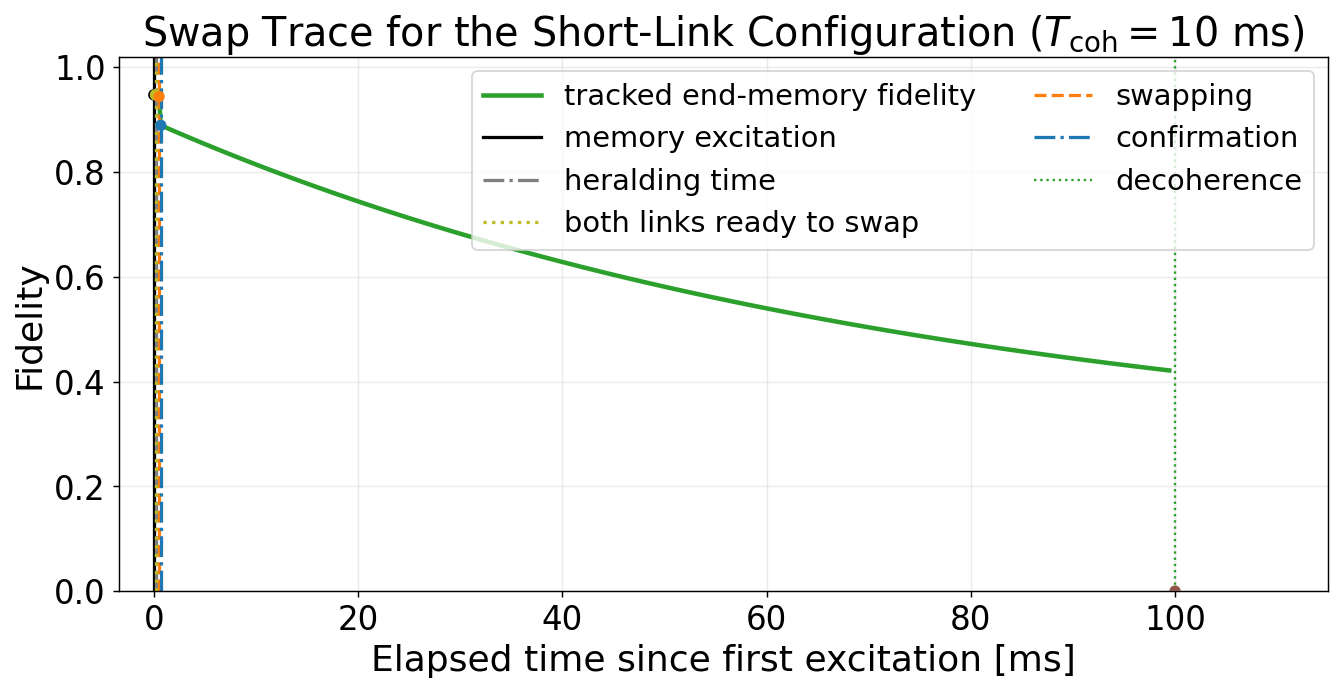

,metric,value
0,tracked side,left
1,seed used,470003
2,herald time [ms],0.17
3,both ready time [ms],0.17
4,swap time [ms],0.51
5,confirm time [ms],0.68
6,protocol pairing delay [ms],0.34
7,tracked wait [ms],0.34
8,other wait [ms],0.62
9,refreshed final fidelity,0.889218


In [115]:
if not behavior_trace.get('success'):
    raise RuntimeError('No successful 32 km / 18 km behavior trace was found.')

times_ms = np.array(behavior_trace['elapsed_times_s'], dtype=float) * 1e3
after_trace = np.array(behavior_trace['after_trace'], dtype=float)
herald_ms = behavior_trace['herald_time_s'] * 1e3
ready_ms = behavior_trace['ready_time_s'] * 1e3
swap_ms = behavior_trace['swap_time_s'] * 1e3
confirm_ms = behavior_trace['confirm_time_s'] * 1e3
pre_cutoff_ms = behavior_trace['pre_swap_cutoff_time_s'] * 1e3
decoherence_ms = behavior_trace['pre_swap_coherence_time_s'] * 1e3
post_cutoff_ms = behavior_trace['post_swap_cutoff_time_s'] * 1e3
post_coherence_ms = behavior_trace['post_swap_coherence_time_s'] * 1e3
xmax_ms = max(float(times_ms.max()), decoherence_ms * 1.15, post_coherence_ms * 1.15)
xmin_ms = -0.03 * xmax_ms

plt.rcParams.update({'axes.titlesize': 22, 'axes.labelsize': 20, 'xtick.labelsize': 18, 'ytick.labelsize': 18, 'legend.fontsize': 16})
fig, ax = plt.subplots(figsize=(10.2, 5.2), constrained_layout=True)
ax.plot(times_ms, after_trace, color='#2ca02c', linewidth=2.5, label='tracked end-memory fidelity')
for x, color, style, width, label in [
    (0.0, '#000000', '-', 1.8, 'memory excitation'),
    (herald_ms, '#7f7f7f', '-.', 1.8, 'heralding time'),
    (ready_ms, '#bcbd22', ':', 1.8, 'both links ready to swap'),
    (swap_ms, '#ff7f0e', '--', 1.8, 'swapping'),
    (confirm_ms, '#1f77b4', '-.', 1.8, 'confirmation'),
    #(pre_cutoff_ms, '#d62728', '--', 1.3, 'pre cutoff'),
    (decoherence_ms, '#2ca02c', ':', 1.3, 'decoherence'),
    #(post_cutoff_ms, '#8c564b', '--', 2.0, 'post cutoff'),
    #(post_coherence_ms, '#17becf', ':', 2.0, 'post coherence'),
]:
    ax.axvline(x, color=color, linestyle=style, linewidth=width, label=label)
ax.scatter(
    [0.0, herald_ms, ready_ms, swap_ms, confirm_ms, post_cutoff_ms],
    [
        float(np.interp(0.0, times_ms, after_trace)),
        float(np.interp(herald_ms, times_ms, after_trace)),
        float(np.interp(ready_ms, times_ms, after_trace)),
        float(np.interp(swap_ms, times_ms, after_trace)),
        float(behavior_trace['refreshed_end_to_end_fidelity']),
        0.0,
    ],
    color=['#000000', '#7f7f7f', '#bcbd22', '#ff7f0e', '#1f77b4', '#8c564b'],
    zorder=4,
    s=28,
)
ax.set_title('Swap Trace for the Short-Link Configuration ($T_{\mathrm{coh}}=10$ ms)')
ax.set_xlabel('Elapsed time since first excitation [ms]')
ax.set_ylabel('Fidelity')
ax.set_xlim(xmin_ms, xmax_ms)
ax.set_ylim(0.0, 1.02)
ax.grid(alpha=0.25)
ax.legend(loc='upper right', ncol=2)
plt.show()

trace_summary = pd.DataFrame([
    ['tracked side', behavior_trace['tracked_side']],
    ['seed used', behavior_trace['seed_used']],
    ['herald time [ms]', herald_ms],
    ['both ready time [ms]', ready_ms],
    ['swap time [ms]', swap_ms],
    ['confirm time [ms]', confirm_ms],
    ['protocol pairing delay [ms]', behavior_trace['protocol_pairing_delay_s'] * 1e3],
    ['tracked wait [ms]', behavior_trace['tracked_wait_s'] * 1e3],
    ['other wait [ms]', behavior_trace['other_wait_s'] * 1e3],
    #['pre coherence [ms]', pre_coherence_ms],
    #['post coherence [ms]', post_coherence_ms],
    #['pre cutoff [ms]', pre_cutoff_ms],
    #['post cutoff [ms]', post_cutoff_ms],
    ['refreshed final fidelity', behavior_trace['refreshed_end_to_end_fidelity']],
], columns=['metric', 'value'])
display(trace_summary)


## Throughput, Fidelity, And Latency Versus Requested Minimum Fidelity

This continuous-operation sweep uses the same `32 km / 18 km`, `1:1` setup. The throughput is the accepted end-to-end throughput at the requested fidelity. The latency is the mean inter-arrival time between accepted delivered pairs.


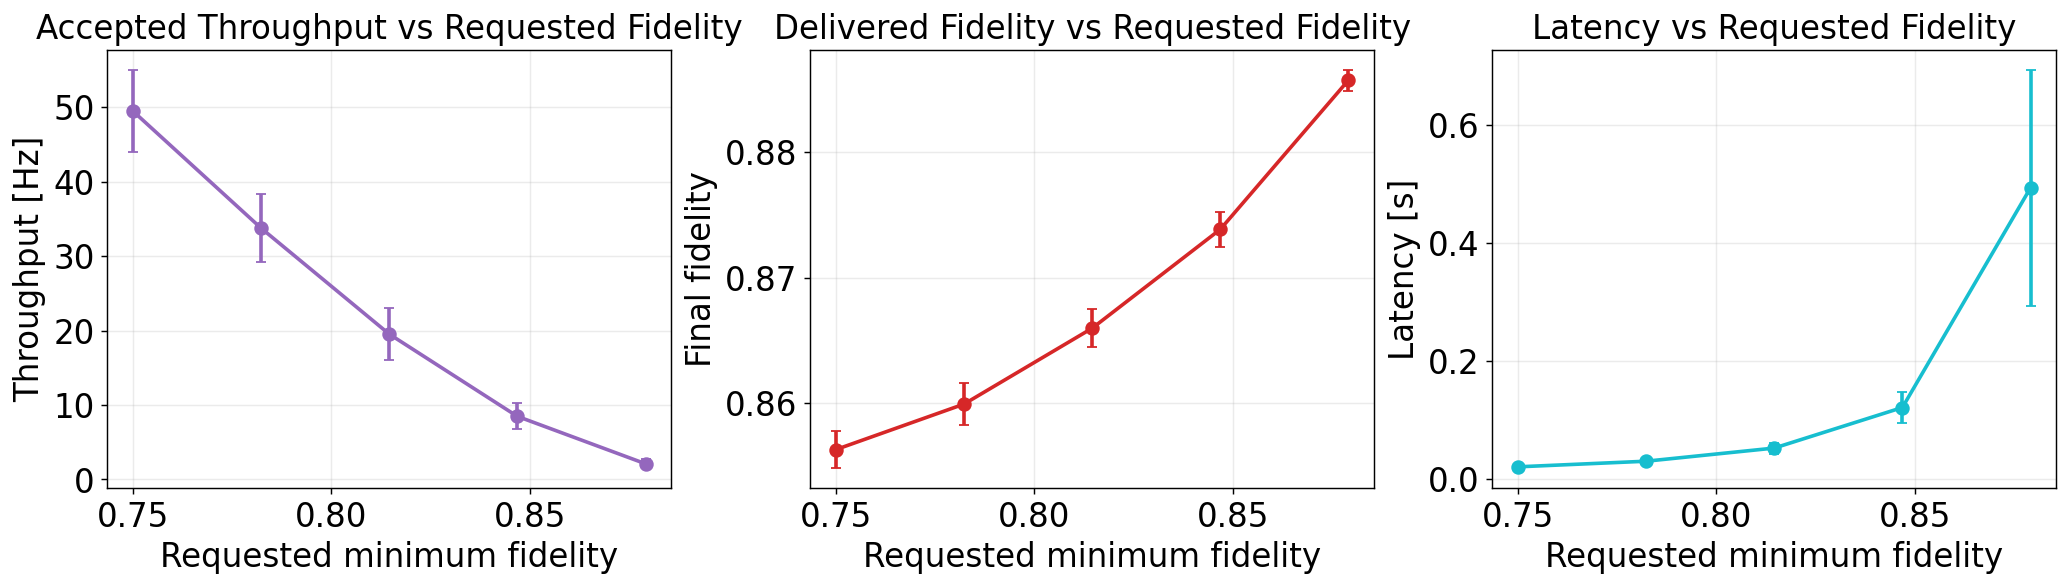

,target_fidelity,throughput_mean,throughput_std,fidelity_mean,fidelity_std,latency_mean_s,latency_std_s,pair_count_mean,pair_count_std
0,0.750000,49.498,5.569723,0.856259,0.001486,0.020333,0.002340,494.98,55.697230
1,0.782287,33.770,4.517989,0.859893,0.001666,0.029838,0.004162,337.70,45.179887
2,0.814574,19.530,3.498874,0.865950,0.001519,0.052110,0.009203,195.30,34.988743
3,0.846861,8.471,1.753225,0.873847,0.001404,0.120843,0.026828,84.71,17.532247
4,0.879148,2.100,0.596623,0.885761,0.000842,0.493157,0.200300,21.00,5.966235


In [116]:
def plot_metric_panel(ax, df, x_key, y_key, yerr_key, color, title, ylabel):
    x = np.array(df[x_key], dtype=float)
    y = np.array(df[y_key], dtype=float)
    yerr = np.array(df[yerr_key], dtype=float)
    ax.errorbar(x, y, yerr=yerr, color=color, marker='o', linewidth=2, capsize=3)
    ax.set_title(title)
    ax.set_xlabel('Requested minimum fidelity')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)

plt.rcParams.update({'axes.titlesize': 18, 'axes.labelsize': 18, 'xtick.labelsize': 18, 'ytick.labelsize': 18, 'legend.fontsize': 16})

fig, axes = plt.subplots(1, 3, figsize=(15.8, 4.4), constrained_layout=True)
plot_metric_panel(axes[0], requested_fidelity_df, 'target_fidelity', 'throughput_mean', 'throughput_std', '#9467bd', 'Accepted Throughput vs Requested Fidelity', 'Throughput [Hz]')
plot_metric_panel(axes[1], requested_fidelity_df, 'target_fidelity', 'fidelity_mean', 'fidelity_std', '#d62728', 'Delivered Fidelity vs Requested Fidelity', 'Final fidelity')
plot_metric_panel(axes[2], requested_fidelity_df, 'target_fidelity', 'latency_mean_s', 'latency_std_s', '#17becf', 'Latency vs Requested Fidelity', 'Latency [s]')
plt.show()

display(requested_fidelity_df)


## Long-Link Cutoff Sweep At Fixed Requested Fidelity

Here only the long elementary link cutoff is changed. The short link stays untouched. The objective is not to prove a single universal best cutoff, but to show that accepted throughput, fidelity, and latency trade off against that cutoff and therefore motivate an operating-point selection problem.


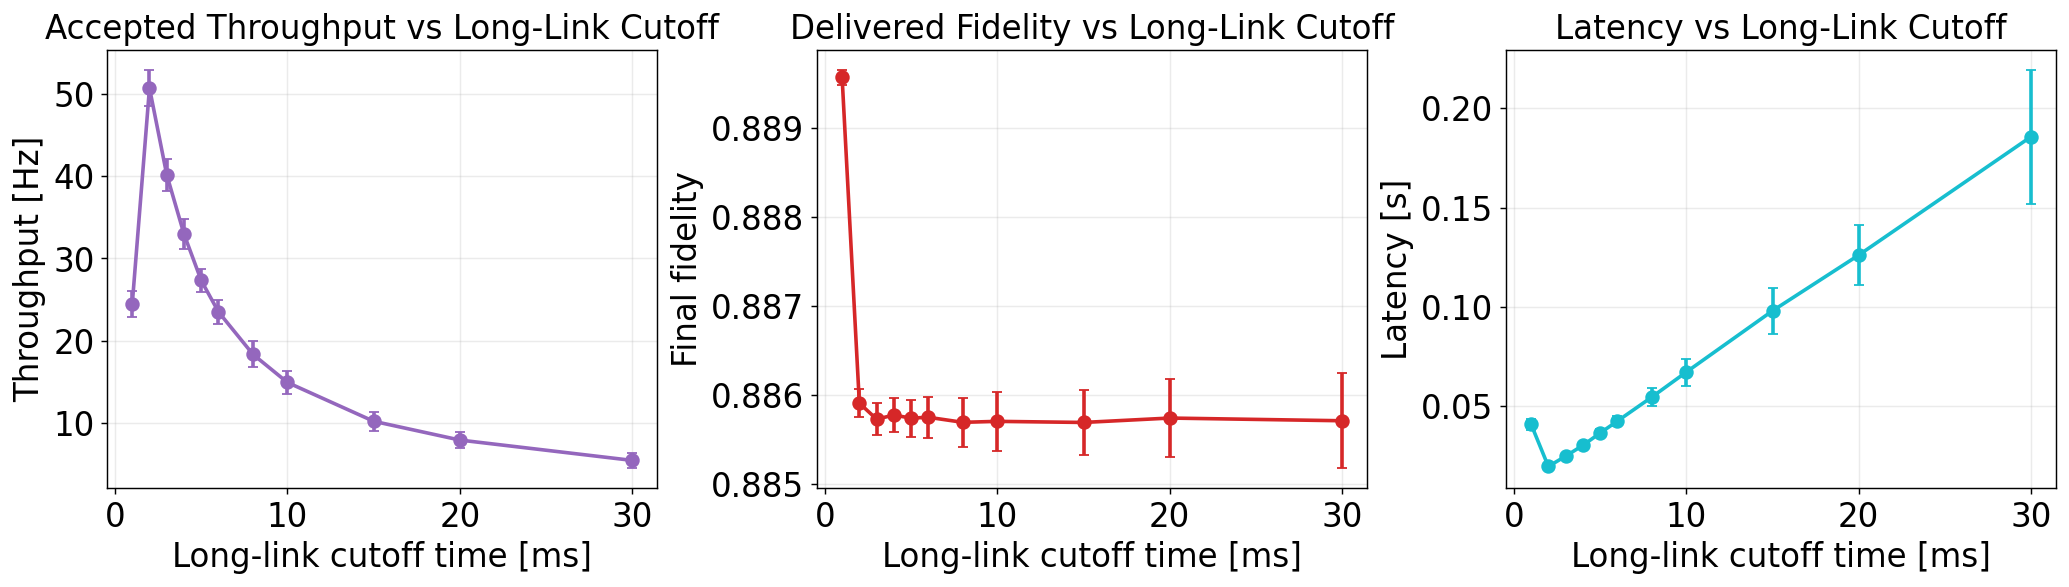

,left_cutoff_time_ms,left_cutoff_ratio,target_fidelity,throughput_mean,throughput_std,fidelity_mean,fidelity_std,latency_mean_s,latency_std_s
0,1.0,0.01,0.879148,24.423,1.560941,0.889568,0.000088,0.040942,0.002632
1,2.0,0.02,0.879148,50.719,2.234834,0.885910,0.000155,0.019711,0.000874
2,3.0,0.03,0.879148,40.178,1.955597,0.885730,0.000183,0.024892,0.001230
3,4.0,0.04,0.879148,32.968,1.777859,0.885776,0.000195,0.030319,0.001625
4,5.0,0.05,0.879148,27.318,1.399955,0.885742,0.000208,0.036527,0.001893
5,6.0,0.06,0.879148,23.496,1.448505,0.885751,0.000229,0.042519,0.002593
6,8.0,0.08,0.879148,18.334,1.574046,0.885695,0.000276,0.054623,0.004693
7,10.0,0.10,0.879148,14.914,1.454357,0.885705,0.000335,0.067206,0.006772
8,15.0,0.15,0.879148,10.195,1.143393,0.885693,0.000361,0.098034,0.011481
9,20.0,0.20,0.879148,7.912,0.921382,0.885743,0.000442,0.126075,0.014937


In [117]:
fig, axes = plt.subplots(1, 3, figsize=(15.8, 4.4), constrained_layout=True)
for ax, y_key, yerr_key, color, title, ylabel in [
    (axes[0], 'throughput_mean', 'throughput_std', '#9467bd', 'Accepted Throughput vs Long-Link Cutoff', 'Throughput [Hz]'),
    (axes[1], 'fidelity_mean', 'fidelity_std', '#d62728', 'Delivered Fidelity vs Long-Link Cutoff', 'Final fidelity'),
    (axes[2], 'latency_mean_s', 'latency_std_s', '#17becf', 'Latency vs Long-Link Cutoff', 'Latency [s]'),
]:
    x = np.array(long_link_cutoff_df['left_cutoff_time_ms'], dtype=float)
    y = np.array(long_link_cutoff_df[y_key], dtype=float)
    yerr = np.array(long_link_cutoff_df[yerr_key], dtype=float)
    ax.errorbar(x, y, yerr=yerr, color=color, marker='o', linewidth=2, capsize=3)
    ax.set_title(title)
    ax.set_xlabel('Long-link cutoff time [ms]')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
plt.show()

display(long_link_cutoff_df)


## Queueing Model Validation Across Allocations

These panels are the model-validation core: requested minimum fidelity on the x-axis, with model and SeQUeNCe throughput/fidelity over the same allocations for multiplexing and non-multiplexing. The optional lower panel shows direct percentage error.


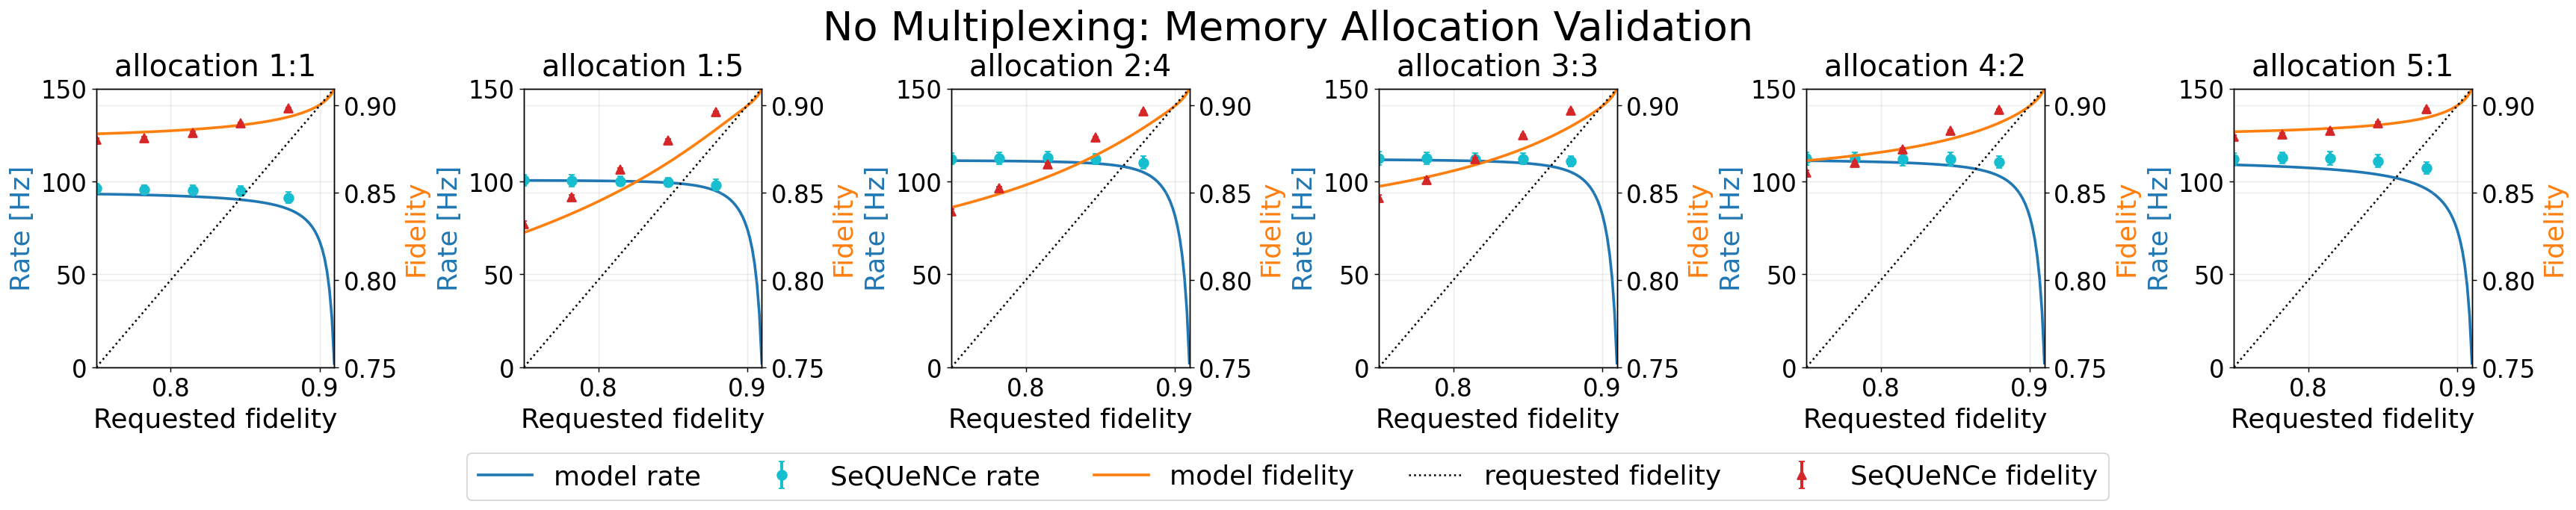

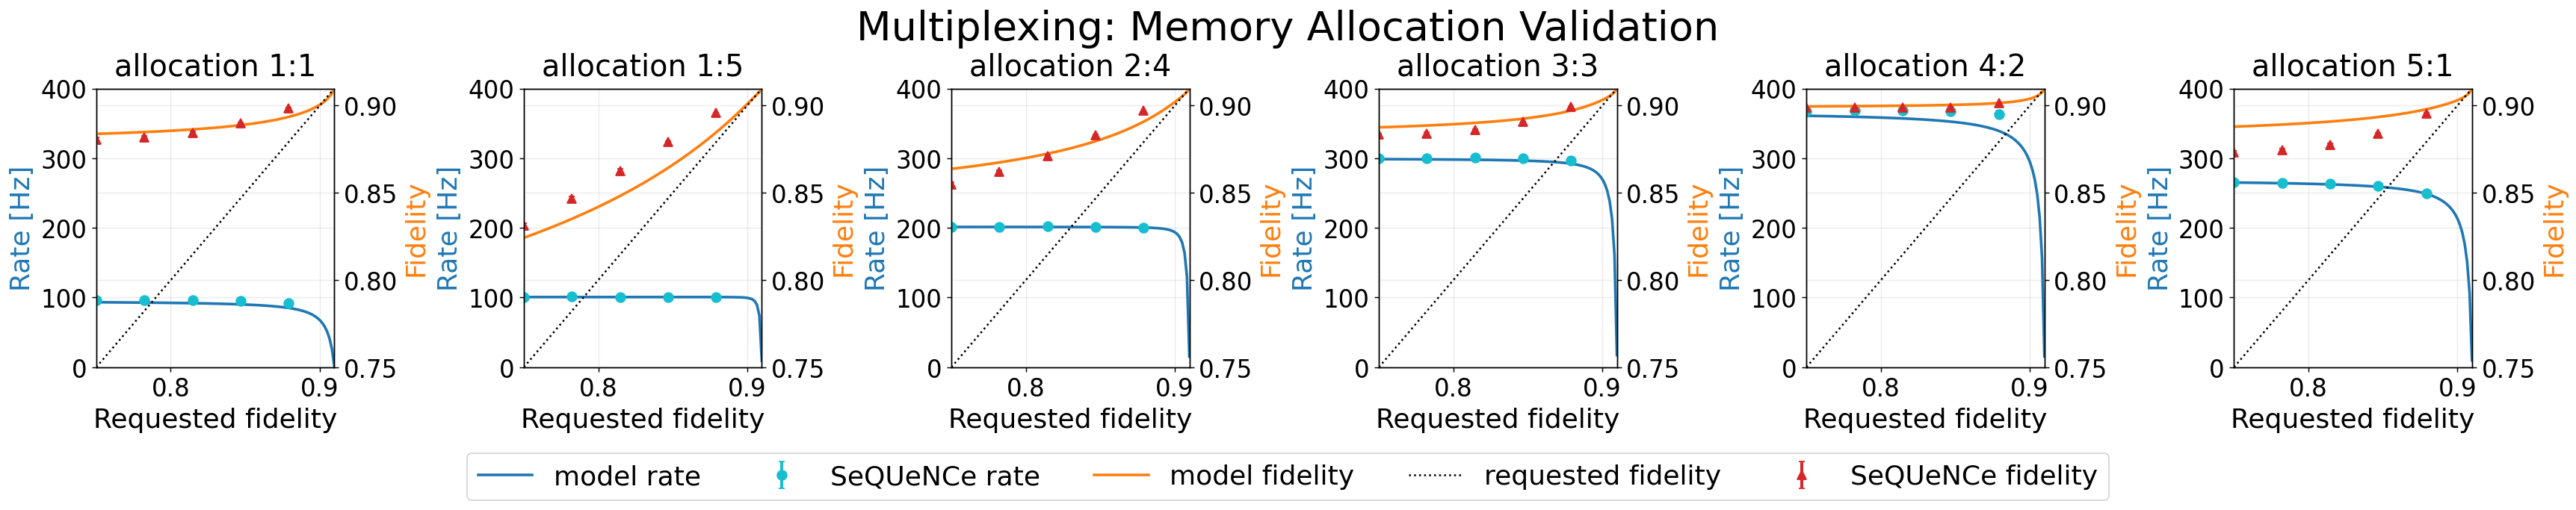

In [118]:
def allocation_label(row):
    return f"{int(row['left_capacity'])}:{int(row['right_capacity'])}"


def add_allocation_label(df):
    df = df.copy()
    df['allocation'] = df.apply(allocation_label, axis=1)
    return df


model_no_mux_df = add_allocation_label(model_no_mux_df)
model_mux_df = add_allocation_label(model_mux_df)
no_mux_df = add_allocation_label(no_mux_df)
mux_df = add_allocation_label(mux_df)


def plot_allocation_validation(model_df, sim_df, title, rate_ylim=None, fidelity_ylim=None, show_error_panel=False):
    allocations = sorted(sim_df['allocation'].unique(), key=lambda s: tuple(map(int, s.split(':'))))
    if rate_ylim is None:
        ymax = max(model_df['model_rate_hz'].max(), sim_df['simulation_rate_hz'].max())
        rate_ylim = (0, np.ceil(ymax / 50) * 50)

    plt.rcParams.update({
        'axes.titlesize': 22,
        'axes.labelsize': 20,
        'xtick.labelsize': 18,
        'ytick.labelsize': 18,
        'legend.fontsize': 20,
    })

    if show_error_panel:
        fig, axes = plt.subplots(2, len(allocations), figsize=(4.4 * len(allocations), 7.7), sharex='col', constrained_layout=True, gridspec_kw={'height_ratios': [3, 1]})
        if len(allocations) == 1:
            axes = np.array(axes).reshape(2, 1)
    else:
        fig, top_axes = plt.subplots(1, len(allocations), figsize=(4.4 * len(allocations), 4), sharex=True, constrained_layout=True)
        if len(allocations) == 1:
            top_axes = np.array([top_axes])
        axes = np.vstack([top_axes, np.array([None] * len(allocations))])

    x_min = min(model_df['required_fidelity'].min(), sim_df['required_fidelity'].min())
    x_max = max(model_df['required_fidelity'].max(), sim_df['required_fidelity'].max())
    if fidelity_ylim is None:
        fidelity_ylim = (x_min, x_max)

    for idx, allocation in enumerate(allocations):
        model_alloc = model_df[model_df['allocation'] == allocation].sort_values('required_fidelity')
        sim_alloc = sim_df[sim_df['allocation'] == allocation].sort_values('required_fidelity')
        ax = axes[0, idx]
        ax_rate = ax
        ax_fid = ax.twinx()
        ax_rate.plot(model_alloc['required_fidelity'], model_alloc['model_rate_hz'], color='tab:blue', linewidth=2.0, label='model rate')
        ax_rate.errorbar(sim_alloc['required_fidelity'], sim_alloc['simulation_rate_hz'], yerr=sim_alloc['simulation_rate_std_hz'], fmt='o', color='#17becf', label='SeQUeNCe rate', capsize=2)
        ax_fid.plot(model_alloc['required_fidelity'], model_alloc['model_fidelity'], color='tab:orange', linewidth=2.0, label='model fidelity')
        ax_fid.errorbar(sim_alloc['required_fidelity'], sim_alloc['simulation_fidelity'], yerr=sim_alloc['simulation_fidelity_std'], fmt='^', color='tab:red', label='SeQUeNCe fidelity', capsize=2)
        ax_fid.plot([x_min, x_max], [x_min, x_max], color='black', linestyle=':', linewidth=1.4, label='requested fidelity')
        ax.set_title(f'allocation {allocation}', pad=10)
        ax.set_xlabel('Requested fidelity')
        ax.set_ylabel('Rate [Hz]', color='tab:blue')
        ax.set_ylim(*rate_ylim)
        ax.set_xlim(x_min, x_max)
        ax_fid.set_ylabel('Fidelity', color='tab:orange')
        ax_fid.set_ylim(*fidelity_ylim)
        if idx == 0:
            shared_handles1, shared_labels1 = ax.get_legend_handles_labels()
            shared_handles2, shared_labels2 = ax_fid.get_legend_handles_labels()
        ax.grid(alpha=0.25)

        if show_error_panel:
            err_ax = axes[1, idx]
            merged = pd.merge_asof(
                sim_alloc[['required_fidelity', 'simulation_rate_hz', 'simulation_fidelity']].sort_values('required_fidelity'),
                model_alloc[['required_fidelity', 'model_rate_hz', 'model_fidelity']].sort_values('required_fidelity'),
                on='required_fidelity',
                direction='nearest',
            )
            rate_err_pct = 100 * (merged['simulation_rate_hz'] - merged['model_rate_hz']) / merged['model_rate_hz']
            fid_err_pct = 100 * (merged['simulation_fidelity'] - merged['model_fidelity']) / merged['model_fidelity']
            err_ax.plot(merged['required_fidelity'], rate_err_pct, marker='o', color='tab:blue', label='rate % diff')
            err_ax.plot(merged['required_fidelity'], fid_err_pct, marker='^', color='tab:orange', label='fidelity % diff')
            err_ax.axhline(0, color='black', linestyle=':', linewidth=1)
            err_ax.set_xlabel('Requested fidelity')
            err_ax.set_ylabel('sim-model [%]')
            err_ax.legend(fontsize=8)
            err_ax.grid(alpha=0.25)
            err_ax.set_xlim(x_min, x_max)

    fig.suptitle(title, fontsize=30, y=1.1)
    fig.legend(
        shared_handles1 + shared_handles2,
        shared_labels1 + shared_labels2,
        loc='lower center',
        ncol=5,
        bbox_to_anchor=(0.5, -0.2),
        frameon=True,
    )
    return fig


plot_allocation_validation(model_no_mux_df, no_mux_df, 'No Multiplexing: Memory Allocation Validation', show_error_panel=False)
plt.show()
plot_allocation_validation(model_mux_df, mux_df, 'Multiplexing: Memory Allocation Validation', show_error_panel=False)
plt.show()


## Accepted-Rate Improvement From Model TTLs

This is the same stacked-bar comparison used earlier for TTL motivation, but here the interpretation is narrower: the bottom stack is accepted end-to-end rate and the top stack is below-target delivered rate. The extra rightmost panel doubles the physical distances to `64 km / 36 km` to show the same TTL effect in a slower regime.


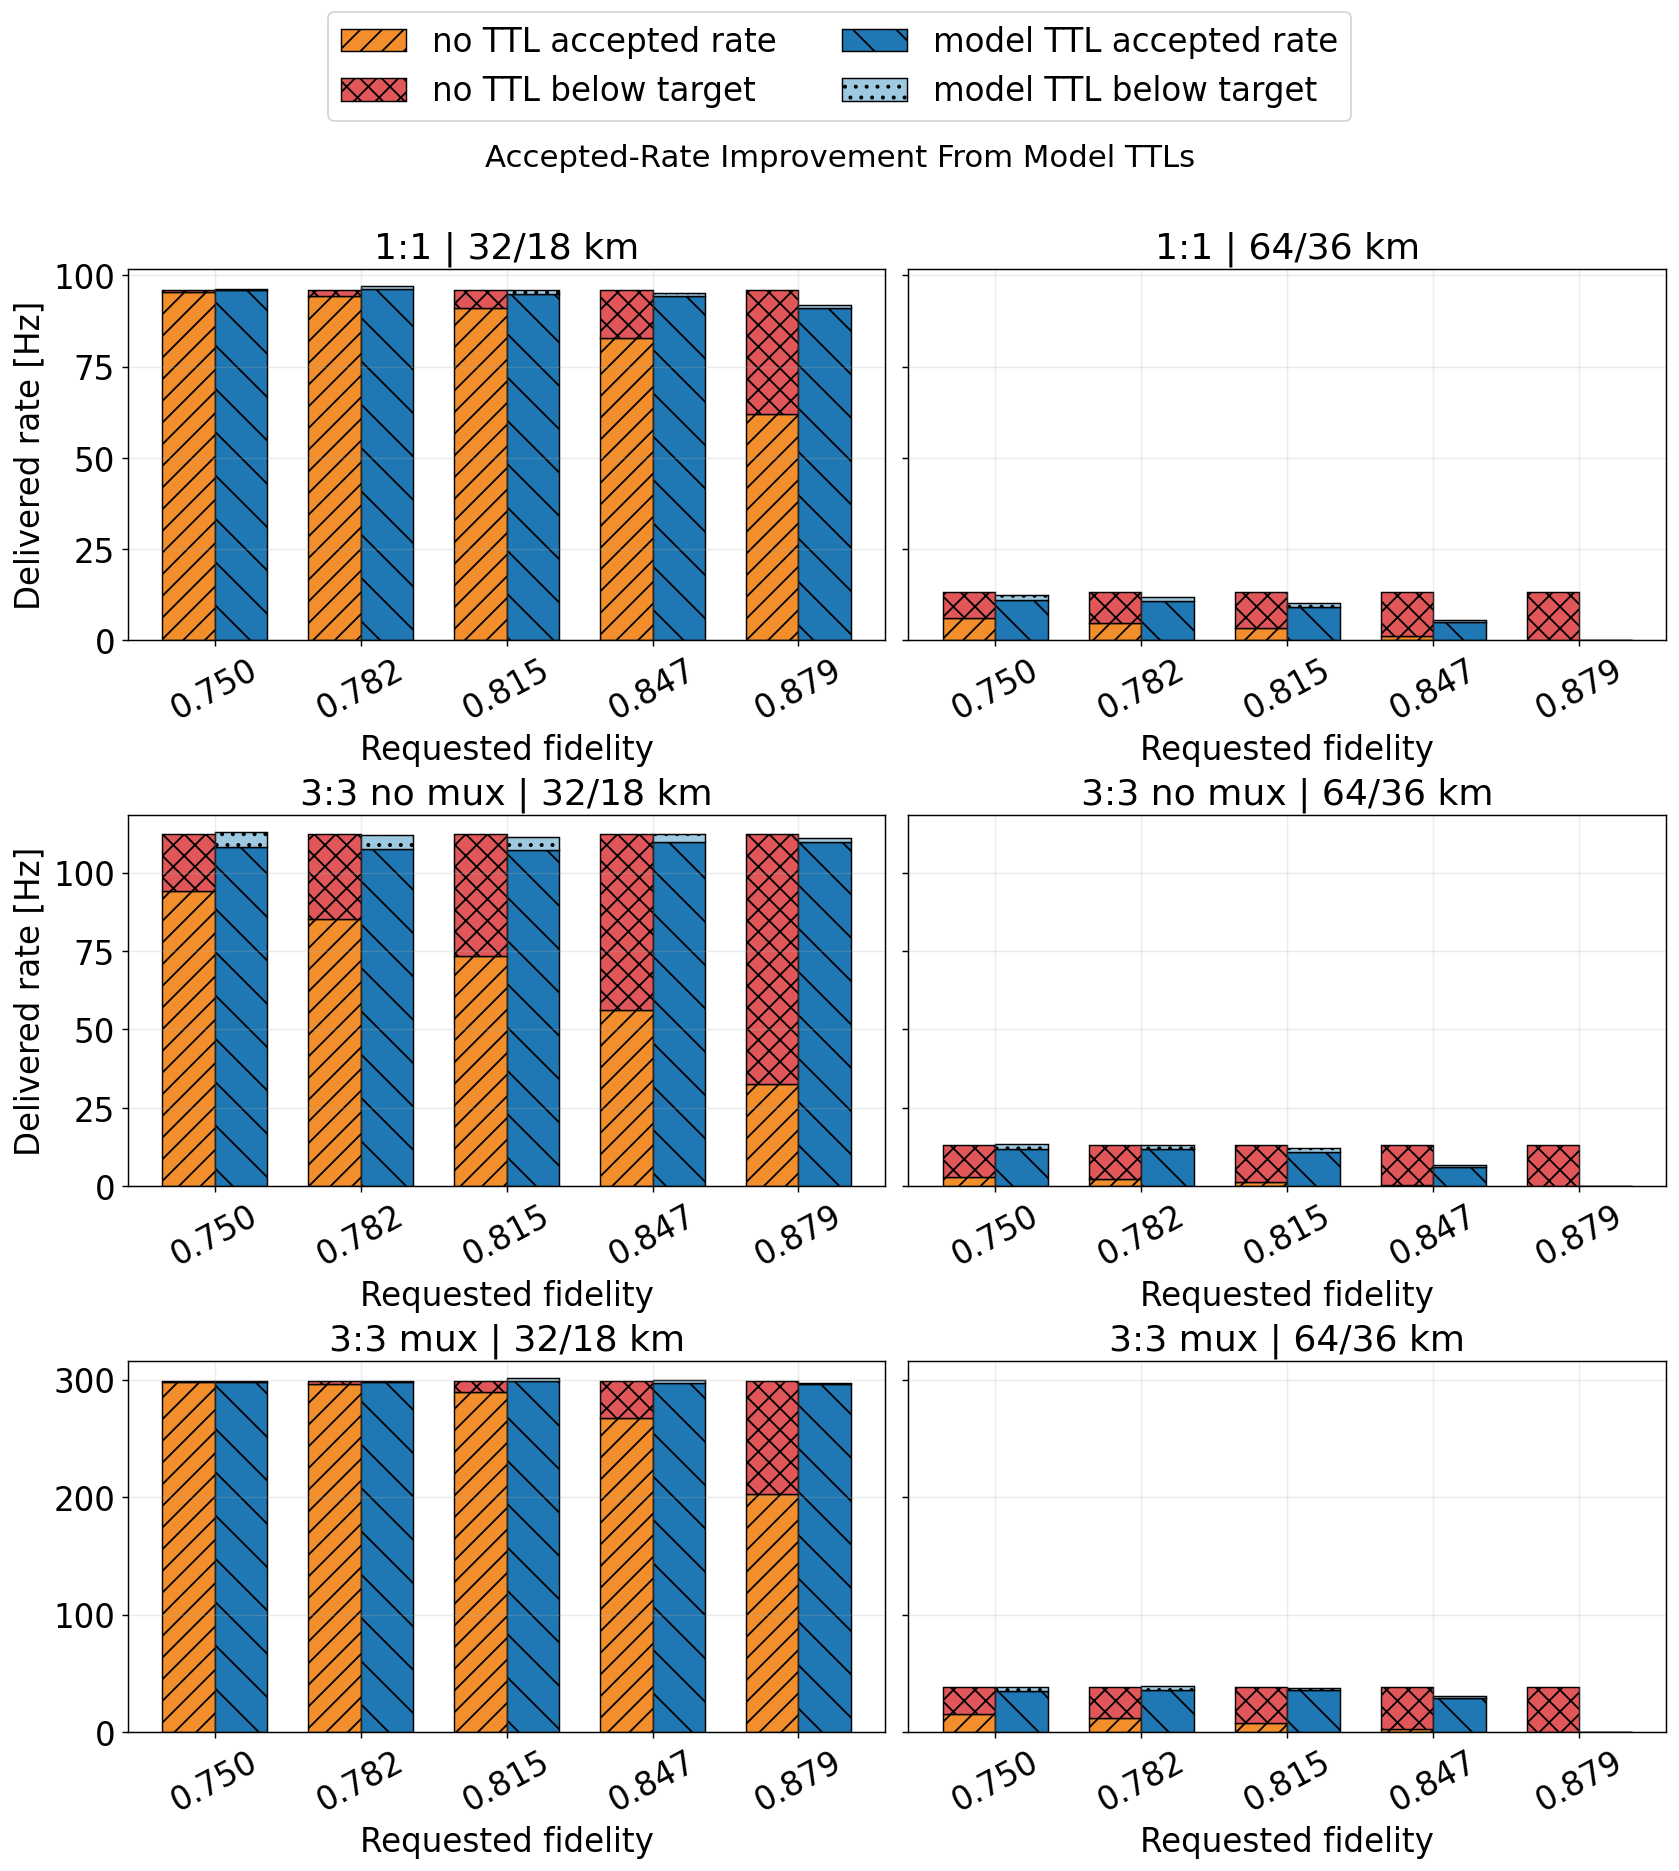

In [119]:
def plot_ttl_improvement_panel(ttl_df):
    ordered_cases = [
        'allocation 1:1',
        'allocation 1:1 | doubled distance',
        'allocation 3:3 | no multiplexing',
        'allocation 3:3 | no multiplexing | doubled distance',
        'allocation 3:3 | multiplexing',
        'allocation 3:3 | multiplexing | doubled distance',
    ]
    pretty_titles = {
        'allocation 1:1': '1:1 | 32/18 km',
        'allocation 3:3 | no multiplexing': '3:3 no mux | 32/18 km',
        'allocation 3:3 | multiplexing': '3:3 mux | 32/18 km',
        'allocation 1:1 | doubled distance': '1:1 | 64/36 km',
        'allocation 3:3 | no multiplexing | doubled distance': '3:3 no mux | 64/36 km',
        'allocation 3:3 | multiplexing | doubled distance': '3:3 mux | 64/36 km',
    }
    summary = (
        ttl_df.groupby(['case_label', 'target_fidelity', 'scenario'], as_index=False)
        [['accepted_rate_hz', 'below_target_rate_hz']]
        .mean()
    )

    plt.rcParams.update({
        'axes.titlesize': 20,
        'axes.labelsize': 18,
        'xtick.labelsize': 18,
        'ytick.labelsize': 18,
        'legend.fontsize': 18,
    })

    fig, axes = plt.subplots(3, 2, figsize=(12.8, 12.6), constrained_layout=True, sharey='row')
    axes = np.asarray(axes)
    width = 0.36
    style = {
        'no_accept': {'color': '#f28e2b', 'hatch': '//', 'edgecolor': 'black', 'linewidth': 0.8},
        'no_below': {'color': '#e15759', 'hatch': 'xx', 'edgecolor': 'black', 'linewidth': 0.8},
        'ttl_accept': {'color': '#1f77b4', 'hatch': '\\', 'edgecolor': 'black', 'linewidth': 0.8},
        'ttl_below': {'color': '#9ecae1', 'hatch': '..', 'edgecolor': 'black', 'linewidth': 0.8},
    }

    for ax, case_label in zip(axes.flat, ordered_cases):
        case_df = summary[summary['case_label'] == case_label].copy().sort_values(['target_fidelity', 'scenario'])
        if case_df.empty:
            ax.text(0.5, 0.5, 'missing data\nrerun backend generation', ha='center', va='center', transform=ax.transAxes, fontsize=12)
            ax.set_title(pretty_titles.get(case_label, case_label))
            ax.set_axis_off()
            continue
        targets = sorted(case_df['target_fidelity'].unique())
        x = np.arange(len(targets), dtype=float)
        no_df = case_df[case_df['scenario'] == 'no TTL'].sort_values('target_fidelity')
        ttl_case = case_df[case_df['scenario'] == 'model TTL'].sort_values('target_fidelity')
        no_accept = no_df['accepted_rate_hz'].to_numpy(float)
        no_below = no_df['below_target_rate_hz'].to_numpy(float)
        ttl_accept = ttl_case['accepted_rate_hz'].to_numpy(float)
        ttl_below = ttl_case['below_target_rate_hz'].to_numpy(float)

        ax.bar(x - width / 2, no_accept, width, label='no TTL accepted rate', **style['no_accept'])
        ax.bar(x - width / 2, no_below, width, bottom=no_accept, label='no TTL below target', **style['no_below'])
        ax.bar(x + width / 2, ttl_accept, width, label='model TTL accepted rate', **style['ttl_accept'])
        ax.bar(x + width / 2, ttl_below, width, bottom=ttl_accept, label='model TTL below target', **style['ttl_below'])
        ax.set_title(pretty_titles.get(case_label, case_label))
        ax.set_xlabel('Requested fidelity')
        ax.set_xticks(x)
        ax.set_xticklabels([f'{value:.3f}' for value in targets], rotation=28)
        ax.grid(alpha=0.25, axis='y')

    axes[0, 0].set_ylabel('Delivered rate [Hz]')
    axes[1, 0].set_ylabel('Delivered rate [Hz]')
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.14), frameon=True)
    fig.suptitle('Accepted-Rate Improvement From Model TTLs', fontsize=17, y=1.05)
    return fig


plot_ttl_improvement_panel(ttl_motivation_df)
plt.show()
